In [2]:
# ============================================================
# Social Network Analysis with R — Google Colab version
# Runtime: Runtime > Change runtime type > R
# ============================================================

# --- Cell 1: install packages (takes ~1-2 min first time) ---
install.packages(c("igraph", "ggraph", "tidygraph", "dplyr", "stringr"))

library(igraph)
library(ggraph)
library(tidygraph)
library(dplyr)
library(stringr)



Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2


Attaching package: ‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
uploaded <- IRdisplay::display  # placeholder, actual upload widget below


In [6]:
tweets <- read.csv("/content/BJP09192022.csv") # Assuming this is the tweets data; adjust filename if needed
tweets$retweeted_from <- str_extract(tweets$text, "(?<=RT @)[A-Za-z0-9_]+")

edges <- tweets %>%
  filter(isRetweet == TRUE, !is.na(retweeted_from)) %>%
  transmute(from = screenName, to = retweeted_from) %>%
  filter(from != to) %>%
  count(from, to, name = "weight")

cat("Total retweet edges (unique pairs):", nrow(edges), "\n")

# Trim to most active users so the graph stays readable
top_n_users <- 150
active_users <- tweets %>%
  count(screenName, sort = TRUE) %>%
  slice_head(n = top_n_users) %>%
  pull(screenName)

edges_sub <- edges %>%
  filter(from %in% active_users | to %in% active_users)

Total retweet edges (unique pairs): 2048 


In [7]:
g <- graph_from_data_frame(edges_sub, directed = TRUE)
g <- simplify(g, remove.multiple = FALSE, remove.loops = TRUE)

cat("Nodes:", vcount(g), " Edges:", ecount(g), "\n")



Nodes: 706  Edges: 705 


In [8]:
density_val      <- edge_density(g)
transitivity_val <- transitivity(g, type = "global")

in_deg  <- degree(g, mode = "in")
out_deg <- degree(g, mode = "out")
betw    <- betweenness(g, directed = TRUE)
eigen_c <- eigen_centrality(g, directed = TRUE)$vector

centrality_df <- data.frame(
  user = V(g)$name,
  retweeted_by_others = in_deg,
  retweets_others = out_deg,
  betweenness = round(betw, 2),
  eigenvector = round(eigen_c, 4)
) %>% arrange(desc(retweeted_by_others))

cat("Density:", density_val, "\n")
cat("Transitivity:", transitivity_val, "\n")
print(head(centrality_df, 15))

write.csv(centrality_df, "/content/centrality_measures.csv", row.names = FALSE)



Density: 0.001416431 
Transitivity: 0.001344555 
                           user retweeted_by_others retweets_others betweenness
ani_digital         ani_digital                 123               0           0
TimesNow               TimesNow                  92               0           0
timesofindia       timesofindia                  82               0           0
CNNnews18             CNNnews18                  79               1          76
the_hindu             the_hindu                  36               0           0
JKGogulBalaji     JKGogulBalaji                  26               0           0
news18dotcom       news18dotcom                  21               1          18
aakash_Boxerbjp aakash_Boxerbjp                  15               1          10
IndiaToday           IndiaToday                  15               0           0
BharatJoda           BharatJoda                  13               1          13
FWACorruption     FWACorruption                  10               0    

In [9]:
# --- Cell 6: most influential nodes -----------------------------------
most_retweeted <- centrality_df$user[which.max(centrality_df$retweeted_by_others)]
most_active    <- centrality_df$user[which.max(centrality_df$retweets_others)]
top_bridge     <- centrality_df$user[which.max(centrality_df$betweenness)]

cat("Most retweeted (influencer):", most_retweeted, "\n")
cat("Most active retweeter:", most_active, "\n")
cat("Top bridge/broker (betweenness):", top_bridge, "\n")



Most retweeted (influencer): ani_digital 
Most active retweeter: KattarActivist 
Top bridge/broker (betweenness): CNNnews18 


In [10]:
communities <- cluster_louvain(as.undirected(g))
V(g)$community <- membership(communities)
cat("Communities detected:", length(communities), "\n")


Warning message:
“`as.undirected()` was deprecated in igraph 2.1.0.
ℹ Please use `as_undirected()` instead.”


Communities detected: 48 


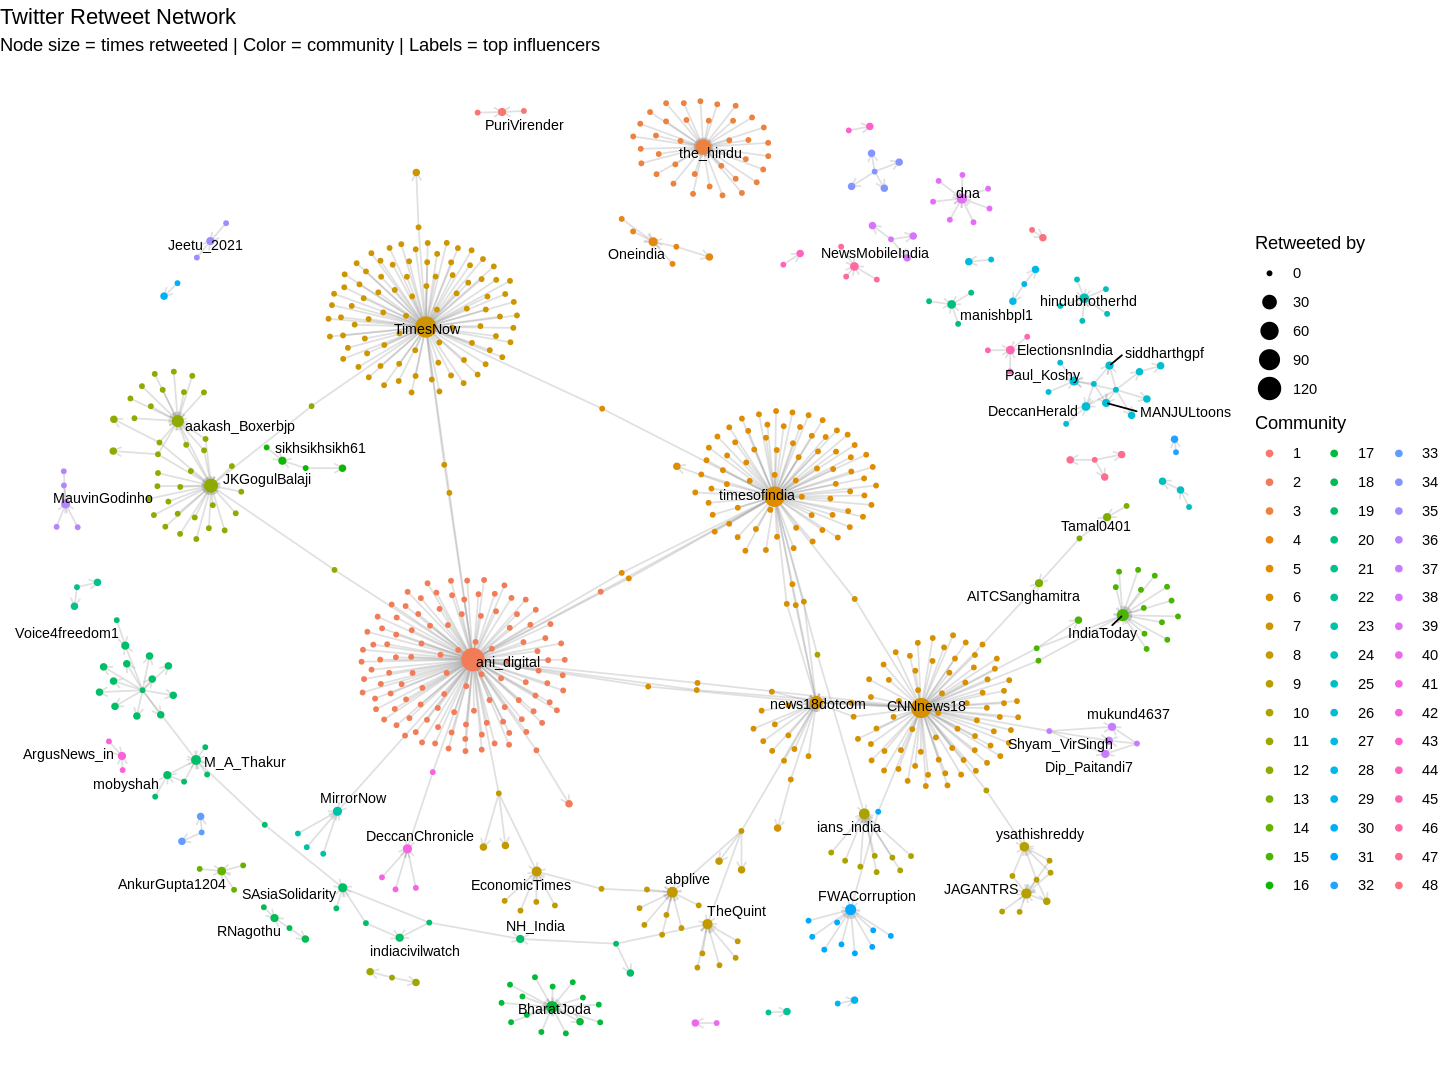

In [11]:
set.seed(42)
tg <- as_tbl_graph(g)

options(repr.plot.width = 12, repr.plot.height = 9)  # Colab plot size

p <- ggraph(tg, layout = "fr") +
  geom_edge_link(arrow = arrow(length = unit(2, "mm")), alpha = 0.3, color = "grey60") +
  geom_node_point(aes(size = in_deg, color = factor(community))) +
  geom_node_text(aes(label = ifelse(in_deg > quantile(in_deg, 0.9), name, "")),
                 repel = TRUE, size = 3) +
  theme_void() +
  labs(title = "Twitter Retweet Network",
       subtitle = "Node size = times retweeted | Color = community | Labels = top influencers",
       size = "Retweeted by", color = "Community")

print(p)
ggsave("/content/retweet_network.png", p, width = 10, height = 8, dpi = 150)



In [12]:
cat("\n---- INTERPRETATION SUMMARY ----\n")
cat("Network:", vcount(g), "users,", ecount(g), "retweet connections.\n")
cat(most_retweeted, "is the most retweeted account -> opinion leader/influencer.\n")
cat(most_active, "retweets others most frequently -> active amplifier.\n")
cat(top_bridge, "has highest betweenness -> connects otherwise separate clusters.\n")
cat("Louvain found", length(communities), "communities, indicating distinct user groups.\n")




---- INTERPRETATION SUMMARY ----
Network: 706 users, 705 retweet connections.
ani_digital is the most retweeted account -> opinion leader/influencer.
KattarActivist retweets others most frequently -> active amplifier.
CNNnews18 has highest betweenness -> connects otherwise separate clusters.
Louvain found 48 communities, indicating distinct user groups.
